In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/transactions.csv", encoding="ISO-8859-1")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11701 entries, 0 to 11700
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    11701 non-null  int64  
 1   CustomerID   11701 non-null  int64  
 2   InvoiceDate  11701 non-null  str    
 3   Product      11701 non-null  str    
 4   Quantity     11701 non-null  int64  
 5   UnitPrice    11701 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 548.6 KB


In [3]:
import os
print(os.getcwd())

C:\Users\HP\Desktop\Customer-Segmentation-Project\notebooks


In [4]:
df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

df = df.dropna(subset=['CustomerID'])

df.drop_duplicates(inplace=True)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.isnull().sum()

InvoiceNo      0
CustomerID     0
InvoiceDate    0
Product        0
Quantity       0
UnitPrice      0
TotalPrice     0
dtype: int64

In [5]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,10000,55,1,514.35
1,10001,411,9,3021.50
2,10002,122,1,69.37
3,10003,28,2,204.28
4,10004,244,8,3166.53


In [6]:
rfm.shape

(500, 4)

In [7]:
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])

rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])

rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

rfm_log.head()

,CustomerID,Recency,Frequency,Monetary
0,10000,4.025352,0.693147,6.244846
1,10001,6.021023,2.302585,8.013840
2,10002,4.812184,0.693147,4.253767
3,10003,3.367296,1.098612,5.324375
4,10004,5.501258,2.197225,8.060707


In [8]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

rfm_scaled[:5]

array([[ 0.02776555, -1.59480957, -1.24030392],
       [ 1.63432658,  0.34123739,  0.04715899],
       [ 0.66118372, -1.59480957, -2.68939968],
       [-0.50198437, -1.10706196, -1.91021758],
       [ 1.21590383,  0.21449568,  0.0812691 ]])

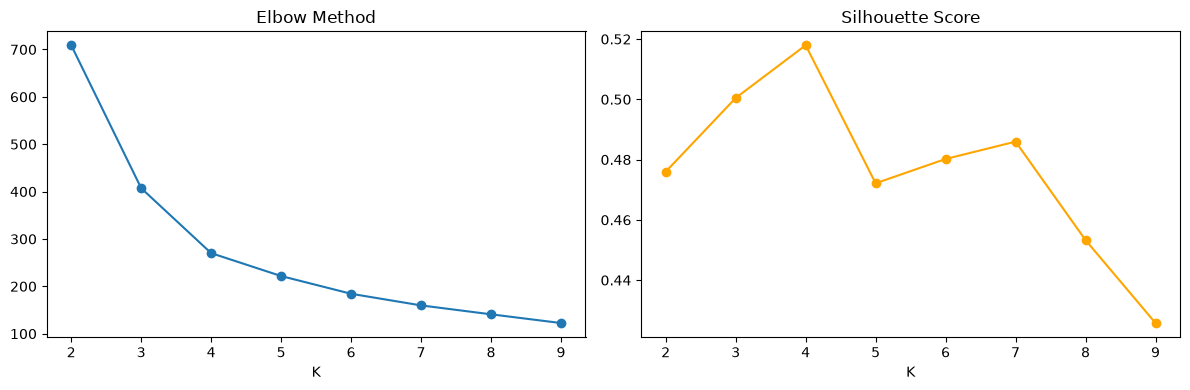

In [9]:
inertia = []
silhouette = []

K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)

    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('K')

ax[1].plot(K_range, silhouette, marker='o', color='orange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('K')

plt.tight_layout()
plt.savefig('../outputs/k_selection.png')
plt.show()

In [10]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,10000,55,1,514.35,3
1,10001,411,9,3021.50,2
2,10002,122,1,69.37,3
3,10003,28,2,204.28,3
4,10004,244,8,3166.53,2


In [11]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print(cluster_profile)

        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0          16.7      22.1  27860.6    87
1          26.9      12.8   3601.9   129
2         285.8       6.0   3258.2   141
3          65.2       1.7    775.6   143


In [12]:
rfm.to_csv('../outputs/customer_segments.csv', index=False)
print("Saved")

Saved
